In [1]:
import numpy as np   
import pandas as pd    
import seaborn as sns
import matplotlib.pyplot as plt   
import matplotlib.style

from warnings import filterwarnings
filterwarnings("ignore")

%matplotlib inline

In [2]:
pd_data = pd.read_excel("C:/Users/DELL/Downloads/Banking_Project/PD_modelling_dataset.xlsx", sheet_name = 'dataset')

In [3]:
pd_data.head()

,userid,default,acct_amt_added_12_24m,acct_days_in_dc_12_24m,acct_days_in_rem_12_24m,acct_days_in_term_12_24m,acct_incoming_debt_vs_paid_0_24m,acct_status,acct_worst_status_0_3m,acct_worst_status_12_24m,...,num_arch_ok_12_24m,num_arch_rem_0_12m,status_max_archived_0_6_months,status_max_archived_0_12_months,status_max_archived_0_24_months,recovery_debt,sum_capital_paid_acct_0_12m,sum_capital_paid_acct_12_24m,sum_paid_inv_0_12m,time_hours
0,4567129,0.0,0,0.0,0.0,0.0,0.0,1.0,1.0,NaN,...,14.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,178839.0,9.653333
1,2635118,0.0,0,0.0,0.0,0.0,NaN,1.0,1.0,1.0,...,19.0,3.0,1.0,2.0,2.0,0.0,0.0,0.0,49014.0,13.181389
2,4804232,0.0,0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,...,0.0,3.0,1.0,2.0,2.0,0.0,0.0,0.0,124839.0,11.561944
3,1442693,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,21.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,324676.0,15.751111
4,4575322,0.0,0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,7100.0,12.698611


In [4]:
pd_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99976 entries, 0 to 99975
Data columns (total 36 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   userid                            99976 non-null  int64  
 1   default                           89976 non-null  float64
 2   acct_amt_added_12_24m             99976 non-null  int64  
 3   acct_days_in_dc_12_24m            88140 non-null  float64
 4   acct_days_in_rem_12_24m           88140 non-null  float64
 5   acct_days_in_term_12_24m          88140 non-null  float64
 6   acct_incoming_debt_vs_paid_0_24m  40661 non-null  float64
 7   acct_status                       45603 non-null  float64
 8   acct_worst_status_0_3m            45603 non-null  float64
 9   acct_worst_status_12_24m          33215 non-null  float64
 10  acct_worst_status_3_6m            42274 non-null  float64
 11  acct_worst_status_6_12m           39626 non-null  float64
 12  age 

In [5]:
pd_data.shape

(99976, 36)

In [6]:
pd_data.describe().T

,count,mean,std,min,25%,50%,75%,max
userid,99976.0,2.998977e+06,1.154177e+06,1.000053e+06,2.000267e+06,2.998832e+06,4.000641e+06,4.999868e+06
default,89976.0,1.431493e-02,1.187862e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
acct_amt_added_12_24m,99976.0,1.225515e+04,3.548148e+04,0.000000e+00,0.000000e+00,0.000000e+00,4.937250e+03,1.128775e+06
acct_days_in_dc_12_24m,88140.0,2.230429e-01,5.808117e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.650000e+02
acct_days_in_rem_12_24m,88140.0,5.044622e+00,2.286397e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.650000e+02
acct_days_in_term_12_24m,88140.0,2.868958e-01,2.929910e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.700000e+01
acct_incoming_debt_vs_paid_0_24m,40661.0,1.331292e+00,2.648230e+01,0.000000e+00,0.000000e+00,1.520819e-01,6.629522e-01,3.914000e+03
acct_status,45603.0,1.042168e+00,2.027134e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00
acct_worst_status_0_3m,45603.0,1.172905e+00,4.201422e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00
acct_worst_status_12_24m,33215.0,1.337348e+00,5.750430e-01,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00


In [7]:
pd_data.isnull().sum()

userid                                  0
default                             10000
acct_amt_added_12_24m                   0
acct_days_in_dc_12_24m              11836
acct_days_in_rem_12_24m             11836
acct_days_in_term_12_24m            11836
acct_incoming_debt_vs_paid_0_24m    59315
acct_status                         54373
acct_worst_status_0_3m              54373
acct_worst_status_12_24m            66761
acct_worst_status_3_6m              57702
acct_worst_status_6_12m             60350
age                                     0
avg_payment_span_0_12m              23836
avg_payment_span_0_3m               49305
merchant_category                       0
merchant_group                          9
has_paid                            11034
max_paid_inv_0_12m                  11034
max_paid_inv_0_24m                  11034
name_in_email                       11034
num_active_div_by_paid_inv_0_12m    29925
num_active_inv                      11034
num_arch_dc_0_12m                 

In [8]:
pd_data.dropna(subset=['default'], inplace=True)

In [9]:
pd_data['has_paid'] = pd_data['has_paid'].astype('object')
pd_data['default'] = pd_data['default'].astype('object')

In [10]:
pd_data['default'].value_counts()

0.0    88688
1.0     1288
Name: default, dtype: int64

In [11]:
pd_data.shape

(89976, 36)

In [12]:
pd_data.isnull().sum()

userid                                  0
default                                 0
acct_amt_added_12_24m                   0
acct_days_in_dc_12_24m              10683
acct_days_in_rem_12_24m             10683
acct_days_in_term_12_24m            10683
acct_incoming_debt_vs_paid_0_24m    53357
acct_status                         48934
acct_worst_status_0_3m              48934
acct_worst_status_12_24m            60055
acct_worst_status_3_6m              51938
acct_worst_status_6_12m             54313
age                                     0
avg_payment_span_0_12m              21468
avg_payment_span_0_3m               44382
merchant_category                       0
merchant_group                          9
has_paid                             9944
max_paid_inv_0_12m                   9944
max_paid_inv_0_24m                   9944
name_in_email                        9944
num_active_div_by_paid_inv_0_12m    26936
num_active_inv                       9944
num_arch_dc_0_12m                 

In [13]:
pd_data.isnull().sum()/pd_data.shape[0]

userid                              0.000000
default                             0.000000
acct_amt_added_12_24m               0.000000
acct_days_in_dc_12_24m              0.118732
acct_days_in_rem_12_24m             0.118732
acct_days_in_term_12_24m            0.118732
acct_incoming_debt_vs_paid_0_24m    0.593014
acct_status                         0.543856
acct_worst_status_0_3m              0.543856
acct_worst_status_12_24m            0.667456
acct_worst_status_3_6m              0.577243
acct_worst_status_6_12m             0.603639
age                                 0.000000
avg_payment_span_0_12m              0.238597
avg_payment_span_0_3m               0.493265
merchant_category                   0.000000
merchant_group                      0.000100
has_paid                            0.110518
max_paid_inv_0_12m                  0.110518
max_paid_inv_0_24m                  0.110518
name_in_email                       0.110518
num_active_div_by_paid_inv_0_12m    0.299369
num_active

In [14]:
for col_value in pd_data.columns:
    if((pd_data[col_value].isnull().sum()/pd_data.shape[0]) >= 0.3):
        pd_data.drop(columns = col_value, inplace = True)

pd_data.isnull().sum()/pd_data.shape[0]

userid                              0.000000
default                             0.000000
acct_amt_added_12_24m               0.000000
acct_days_in_dc_12_24m              0.118732
acct_days_in_rem_12_24m             0.118732
acct_days_in_term_12_24m            0.118732
age                                 0.000000
avg_payment_span_0_12m              0.238597
merchant_category                   0.000000
merchant_group                      0.000100
has_paid                            0.110518
max_paid_inv_0_12m                  0.110518
max_paid_inv_0_24m                  0.110518
name_in_email                       0.110518
num_active_div_by_paid_inv_0_12m    0.299369
num_active_inv                      0.110518
num_arch_dc_0_12m                   0.110518
num_arch_dc_12_24m                  0.110518
num_arch_ok_0_12m                   0.110518
num_arch_ok_12_24m                  0.110518
num_arch_rem_0_12m                  0.110518
status_max_archived_0_6_months      0.110518
status_max

In [15]:
pd_data.drop(columns = ['name_in_email','userid'], inplace = True)

In [16]:
pd_data.columns

Index(['default', 'acct_amt_added_12_24m', 'acct_days_in_dc_12_24m',
       'acct_days_in_rem_12_24m', 'acct_days_in_term_12_24m', 'age',
       'avg_payment_span_0_12m', 'merchant_category', 'merchant_group',
       'has_paid', 'max_paid_inv_0_12m', 'max_paid_inv_0_24m',
       'num_active_div_by_paid_inv_0_12m', 'num_active_inv',
       'num_arch_dc_0_12m', 'num_arch_dc_12_24m', 'num_arch_ok_0_12m',
       'num_arch_ok_12_24m', 'num_arch_rem_0_12m',
       'status_max_archived_0_6_months', 'status_max_archived_0_12_months',
       'status_max_archived_0_24_months', 'recovery_debt',
       'sum_capital_paid_acct_0_12m', 'sum_capital_paid_acct_12_24m',
       'sum_paid_inv_0_12m', 'time_hours'],
      dtype='object')

In [17]:
qualitative_list = []
quantitative_list = []

# Loop through each column in the DataFrame
for col_value in pd_data.columns:
    # If the column has a data type of 'object' or 'category', append it to qualitative_list; otherwise append it to quantitative_list
    if pd_data[col_value].dtype == 'object' or pd_data[col_value].dtype.name == 'category':
        qualitative_list.append(col_value)
    else:
        quantitative_list.append(col_value)

print("Qualitative Variable list:",qualitative_list)
print("Quantitative Variable list:",quantitative_list)

Qualitative Variable list: ['default', 'merchant_category', 'merchant_group', 'has_paid']
Quantitative Variable list: ['acct_amt_added_12_24m', 'acct_days_in_dc_12_24m', 'acct_days_in_rem_12_24m', 'acct_days_in_term_12_24m', 'age', 'avg_payment_span_0_12m', 'max_paid_inv_0_12m', 'max_paid_inv_0_24m', 'num_active_div_by_paid_inv_0_12m', 'num_active_inv', 'num_arch_dc_0_12m', 'num_arch_dc_12_24m', 'num_arch_ok_0_12m', 'num_arch_ok_12_24m', 'num_arch_rem_0_12m', 'status_max_archived_0_6_months', 'status_max_archived_0_12_months', 'status_max_archived_0_24_months', 'recovery_debt', 'sum_capital_paid_acct_0_12m', 'sum_capital_paid_acct_12_24m', 'sum_paid_inv_0_12m', 'time_hours']


In [18]:
for col_value in quantitative_list:
    if((pd_data[col_value].isnull().sum()/pd_data.shape[0]) > 0):
        pd_data[col_value].fillna(pd_data[col_value].median(), inplace=True)
        
pd_data.isnull().sum()

default                                0
acct_amt_added_12_24m                  0
acct_days_in_dc_12_24m                 0
acct_days_in_rem_12_24m                0
acct_days_in_term_12_24m               0
age                                    0
avg_payment_span_0_12m                 0
merchant_category                      0
merchant_group                         9
has_paid                            9944
max_paid_inv_0_12m                     0
max_paid_inv_0_24m                     0
num_active_div_by_paid_inv_0_12m       0
num_active_inv                         0
num_arch_dc_0_12m                      0
num_arch_dc_12_24m                     0
num_arch_ok_0_12m                      0
num_arch_ok_12_24m                     0
num_arch_rem_0_12m                     0
status_max_archived_0_6_months         0
status_max_archived_0_12_months        0
status_max_archived_0_24_months        0
recovery_debt                          0
sum_capital_paid_acct_0_12m            0
sum_capital_paid

In [19]:
pd_data['merchant_group'].fillna(pd_data['merchant_group'].mode()[0], inplace=True)
pd_data['has_paid'].fillna(pd_data['has_paid'].mode()[0], inplace=True)
        
pd_data.isnull().sum()

default                             0
acct_amt_added_12_24m               0
acct_days_in_dc_12_24m              0
acct_days_in_rem_12_24m             0
acct_days_in_term_12_24m            0
age                                 0
avg_payment_span_0_12m              0
merchant_category                   0
merchant_group                      0
has_paid                            0
max_paid_inv_0_12m                  0
max_paid_inv_0_24m                  0
num_active_div_by_paid_inv_0_12m    0
num_active_inv                      0
num_arch_dc_0_12m                   0
num_arch_dc_12_24m                  0
num_arch_ok_0_12m                   0
num_arch_ok_12_24m                  0
num_arch_rem_0_12m                  0
status_max_archived_0_6_months      0
status_max_archived_0_12_months     0
status_max_archived_0_24_months     0
recovery_debt                       0
sum_capital_paid_acct_0_12m         0
sum_capital_paid_acct_12_24m        0
sum_paid_inv_0_12m                  0
time_hours  

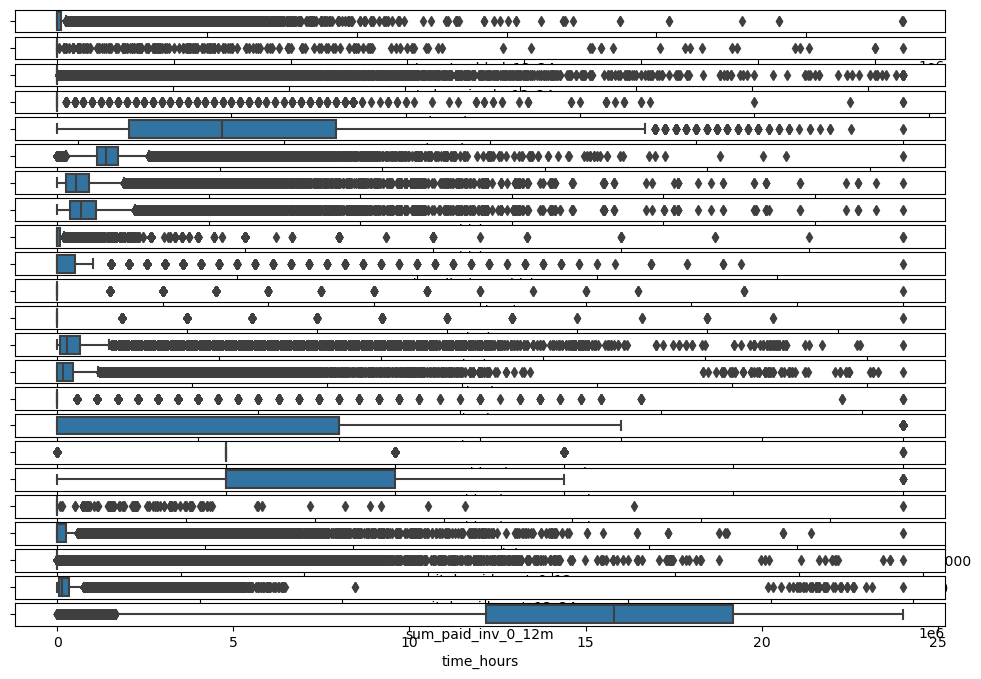

In [20]:
# Create the figure and subplots for quantitative fields
fig, axes = plt.subplots(len(quantitative_list), figsize=(12, 8))
quantitative_list_count = len(quantitative_list)

# Iterate over the subplots and plot bar charts
for i in range(quantitative_list_count):
    plot = sns.boxplot(x = quantitative_list[i], data = pd_data, ax = axes[i])

In [21]:
# Imputing outliers
for cols in quantitative_list:
    IQR = np.quantile(pd_data[cols], 0.75) - np.quantile(pd_data[cols], 0.25)
    pd_data[cols] = np.where(pd_data[cols] > np.quantile(pd_data[cols], 0.75) + 1.5*IQR, np.quantile(pd_data[cols], 0.75), pd_data[cols])
    pd_data[cols] = np.where(pd_data[cols] < np.quantile(pd_data[cols], 0.25) - 1.5*IQR, np.quantile(pd_data[cols], 0.25), pd_data[cols])


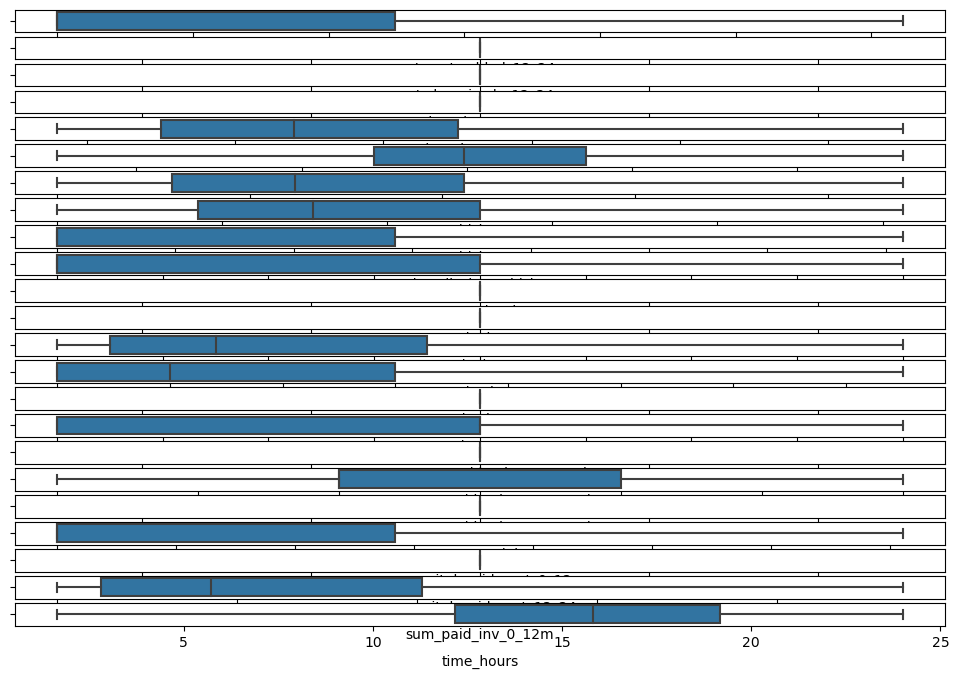

In [22]:
# Create the figure and subplots for quantitative fields
fig, axes = plt.subplots(len(quantitative_list), figsize=(12, 8))
quantitative_list_count = len(quantitative_list)

# Iterate over the subplots and plot bar charts
for i in range(quantitative_list_count):
    plot = sns.boxplot(x = quantitative_list[i], data = pd_data, ax = axes[i])

In [23]:
pd_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 89976 entries, 0 to 89975
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   default                           89976 non-null  object 
 1   acct_amt_added_12_24m             89976 non-null  float64
 2   acct_days_in_dc_12_24m            89976 non-null  float64
 3   acct_days_in_rem_12_24m           89976 non-null  float64
 4   acct_days_in_term_12_24m          89976 non-null  float64
 5   age                               89976 non-null  float64
 6   avg_payment_span_0_12m            89976 non-null  float64
 7   merchant_category                 89976 non-null  object 
 8   merchant_group                    89976 non-null  object 
 9   has_paid                          89976 non-null  float64
 10  max_paid_inv_0_12m                89976 non-null  float64
 11  max_paid_inv_0_24m                89976 non-null  float64
 12  num_

In [24]:
pd_data['has_paid'].astype('object')

0        1.0
1        1.0
2        1.0
3        1.0
4        1.0
        ... 
89971    1.0
89972    1.0
89973    1.0
89974    1.0
89975    1.0
Name: has_paid, Length: 89976, dtype: object

In [25]:
qualitative_list = []
quantitative_list = []

# Loop through each column in the DataFrame
for col_value in pd_data.columns:
    # If the column has a data type of 'object' or 'category', append it to qualitative_list; otherwise append it to quantitative_list
    if pd_data[col_value].dtype == 'object' or pd_data[col_value].dtype.name == 'category':
        qualitative_list.append(col_value)
    else:
        quantitative_list.append(col_value)

print("Qualitative Variable list:",qualitative_list)
print("Quantitative Variable list:",quantitative_list)

Qualitative Variable list: ['default', 'merchant_category', 'merchant_group']
Quantitative Variable list: ['acct_amt_added_12_24m', 'acct_days_in_dc_12_24m', 'acct_days_in_rem_12_24m', 'acct_days_in_term_12_24m', 'age', 'avg_payment_span_0_12m', 'has_paid', 'max_paid_inv_0_12m', 'max_paid_inv_0_24m', 'num_active_div_by_paid_inv_0_12m', 'num_active_inv', 'num_arch_dc_0_12m', 'num_arch_dc_12_24m', 'num_arch_ok_0_12m', 'num_arch_ok_12_24m', 'num_arch_rem_0_12m', 'status_max_archived_0_6_months', 'status_max_archived_0_12_months', 'status_max_archived_0_24_months', 'recovery_debt', 'sum_capital_paid_acct_0_12m', 'sum_capital_paid_acct_12_24m', 'sum_paid_inv_0_12m', 'time_hours']


In [26]:
quantitative_list.remove('has_paid')
qualitative_list.append('has_paid')

In [27]:
print("Qualitative Variable list:",qualitative_list)
print("Quantitative Variable list:",quantitative_list)

Qualitative Variable list: ['default', 'merchant_category', 'merchant_group', 'has_paid']
Quantitative Variable list: ['acct_amt_added_12_24m', 'acct_days_in_dc_12_24m', 'acct_days_in_rem_12_24m', 'acct_days_in_term_12_24m', 'age', 'avg_payment_span_0_12m', 'max_paid_inv_0_12m', 'max_paid_inv_0_24m', 'num_active_div_by_paid_inv_0_12m', 'num_active_inv', 'num_arch_dc_0_12m', 'num_arch_dc_12_24m', 'num_arch_ok_0_12m', 'num_arch_ok_12_24m', 'num_arch_rem_0_12m', 'status_max_archived_0_6_months', 'status_max_archived_0_12_months', 'status_max_archived_0_24_months', 'recovery_debt', 'sum_capital_paid_acct_0_12m', 'sum_capital_paid_acct_12_24m', 'sum_paid_inv_0_12m', 'time_hours']


In [28]:
pd_data['has_paid'].value_counts()

1.0    79231
0.0    10745
Name: has_paid, dtype: int64

In [29]:
pd_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 89976 entries, 0 to 89975
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   default                           89976 non-null  object 
 1   acct_amt_added_12_24m             89976 non-null  float64
 2   acct_days_in_dc_12_24m            89976 non-null  float64
 3   acct_days_in_rem_12_24m           89976 non-null  float64
 4   acct_days_in_term_12_24m          89976 non-null  float64
 5   age                               89976 non-null  float64
 6   avg_payment_span_0_12m            89976 non-null  float64
 7   merchant_category                 89976 non-null  object 
 8   merchant_group                    89976 non-null  object 
 9   has_paid                          89976 non-null  float64
 10  max_paid_inv_0_12m                89976 non-null  float64
 11  max_paid_inv_0_24m                89976 non-null  float64
 12  num_

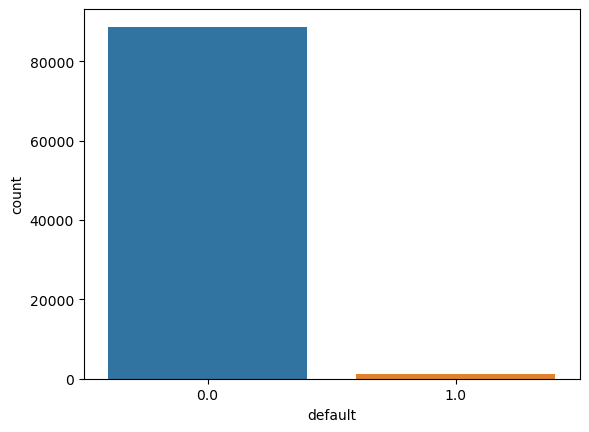

In [30]:
sns.countplot(x = 'default', data = pd_data);

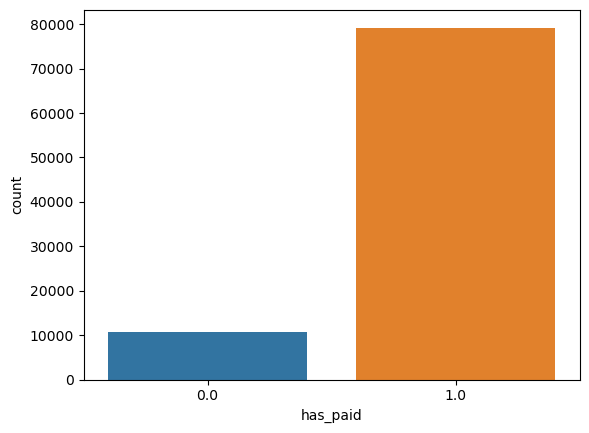

In [31]:
sns.countplot(x = 'has_paid', data = pd_data);

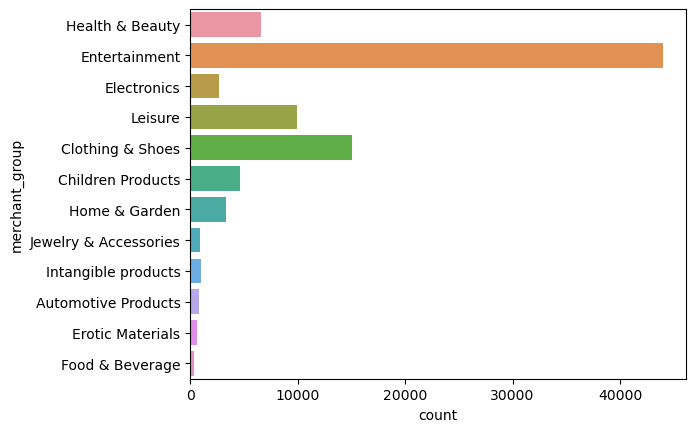

In [32]:
sns.countplot(y = 'merchant_group', data = pd_data);

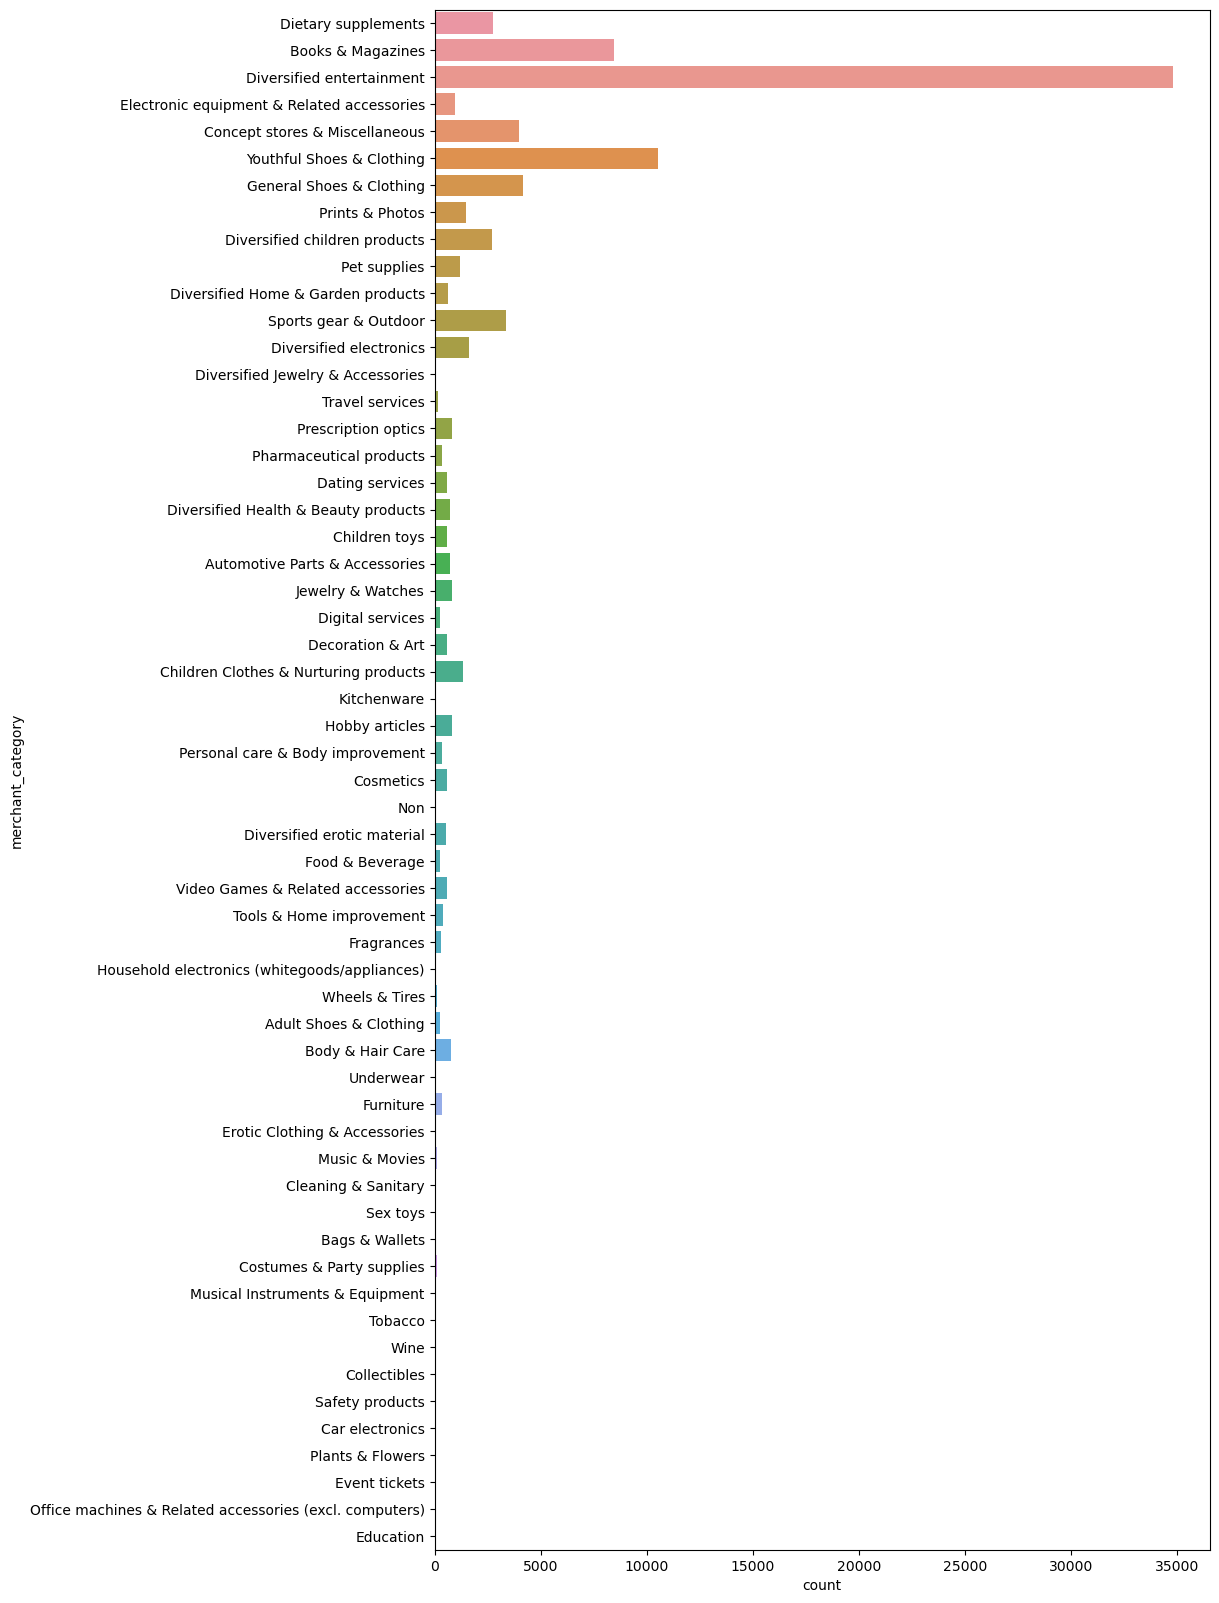

In [33]:
plt.figure(figsize=(10, 20))
sns.countplot(y = 'merchant_category', data = pd_data);

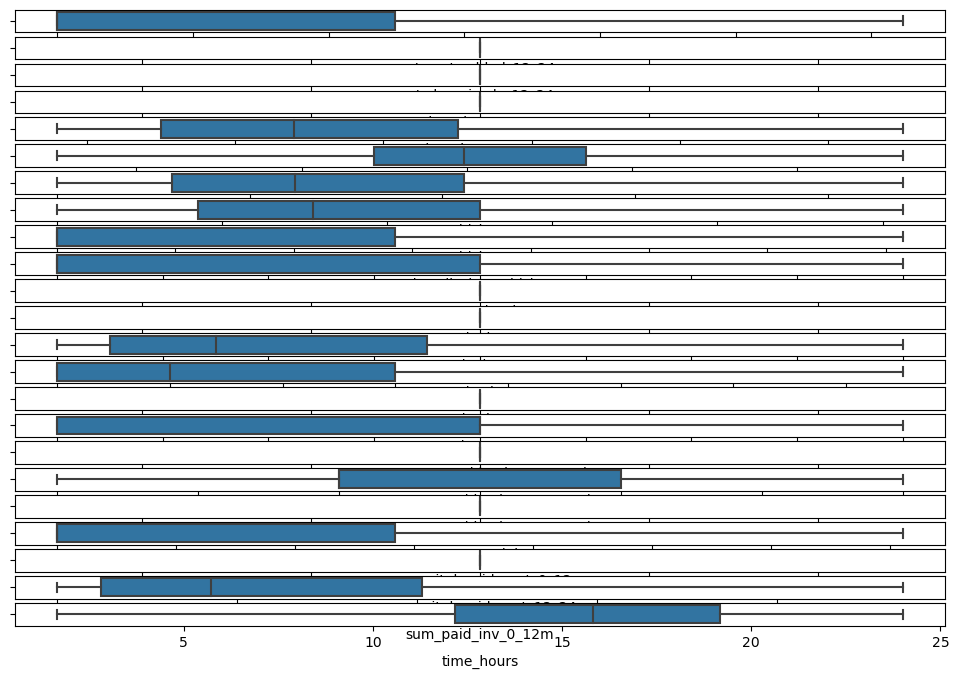

In [34]:
# Create the figure and subplots for quantitative fields
fig, axes = plt.subplots(len(quantitative_list), figsize=(12, 8))
quantitative_list_count = len(quantitative_list)

# Iterate over the subplots and plot bar charts
for i in range(quantitative_list_count):
    plot = sns.boxplot(x = quantitative_list[i], data = pd_data, ax = axes[i])

In [35]:
pd_data.drop(columns=['acct_days_in_dc_12_24m','acct_days_in_rem_12_24m','acct_days_in_term_12_24m','num_arch_dc_0_12m','num_arch_dc_12_24m'
                     ,'num_arch_rem_0_12m','status_max_archived_0_12_months','recovery_debt','sum_capital_paid_acct_12_24m']
            ,inplace=True)

In [36]:
pd_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 89976 entries, 0 to 89975
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   default                           89976 non-null  object 
 1   acct_amt_added_12_24m             89976 non-null  float64
 2   age                               89976 non-null  float64
 3   avg_payment_span_0_12m            89976 non-null  float64
 4   merchant_category                 89976 non-null  object 
 5   merchant_group                    89976 non-null  object 
 6   has_paid                          89976 non-null  float64
 7   max_paid_inv_0_12m                89976 non-null  float64
 8   max_paid_inv_0_24m                89976 non-null  float64
 9   num_active_div_by_paid_inv_0_12m  89976 non-null  float64
 10  num_active_inv                    89976 non-null  float64
 11  num_arch_ok_0_12m                 89976 non-null  float64
 12  num_

In [37]:
pd_data.corr()

,acct_amt_added_12_24m,age,avg_payment_span_0_12m,has_paid,max_paid_inv_0_12m,max_paid_inv_0_24m,num_active_div_by_paid_inv_0_12m,num_active_inv,num_arch_ok_0_12m,num_arch_ok_12_24m,status_max_archived_0_6_months,status_max_archived_0_24_months,sum_capital_paid_acct_0_12m,sum_paid_inv_0_12m,time_hours
acct_amt_added_12_24m,1.000000,-0.076595,0.152014,0.213643,0.161255,0.184130,0.149345,0.156156,0.113717,0.161780,0.168074,0.295227,0.510703,0.172002,0.000063
age,-0.076595,1.000000,0.000916,-0.050737,-0.090475,-0.077537,-0.025145,-0.042709,0.004842,0.030176,-0.038044,-0.077996,-0.073581,-0.044852,0.005796
avg_payment_span_0_12m,0.152014,0.000916,1.000000,0.007017,0.050754,0.043656,0.082722,0.097436,-0.075884,-0.031434,0.159005,0.315128,0.143877,0.041038,-0.003165
has_paid,0.213643,-0.050737,0.007017,1.000000,0.487824,0.525108,0.196834,0.167782,0.375252,0.328362,0.478629,0.576513,0.216158,0.390665,0.006107
max_paid_inv_0_12m,0.161255,-0.090475,0.050754,0.487824,1.000000,0.837808,0.291511,0.237127,0.477621,0.358153,0.502909,0.473865,0.155022,0.695794,-0.000411
max_paid_inv_0_24m,0.184130,-0.077537,0.043656,0.525108,0.837808,1.000000,0.271514,0.229501,0.439358,0.404246,0.450640,0.498798,0.169923,0.635769,-0.001216
num_active_div_by_paid_inv_0_12m,0.149345,-0.025145,0.082722,0.196834,0.291511,0.271514,1.000000,0.833543,0.388304,0.313583,0.295602,0.308225,0.184003,0.404256,-0.003329
num_active_inv,0.156156,-0.042709,0.097436,0.167782,0.237127,0.229501,0.833543,1.000000,0.290118,0.250838,0.240239,0.284569,0.194016,0.334821,-0.002034
num_arch_ok_0_12m,0.113717,0.004842,-0.075884,0.375252,0.477621,0.439358,0.388304,0.290118,1.000000,0.622373,0.495264,0.312441,0.114984,0.712583,-0.000560
num_arch_ok_12_24m,0.161780,0.030176,-0.031434,0.328362,0.358153,0.404246,0.313583,0.250838,0.622373,1.000000,0.359054,0.316588,0.144823,0.523638,0.001719


<AxesSubplot:xlabel='default', ylabel='acct_amt_added_12_24m'>

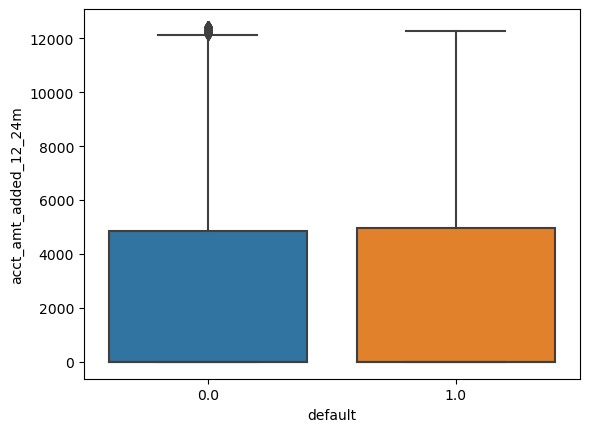

In [38]:
sns.boxplot(y = 'acct_amt_added_12_24m', data = pd_data, x = 'default')

<AxesSubplot:xlabel='default', ylabel='age'>

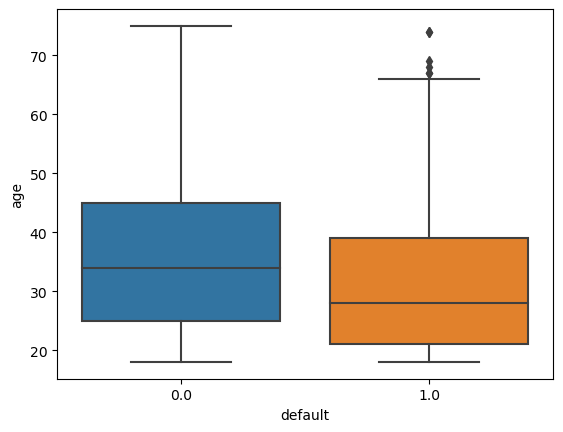

In [39]:
sns.boxplot(y = 'age', data = pd_data, x = 'default')

<AxesSubplot:xlabel='default', ylabel='avg_payment_span_0_12m'>

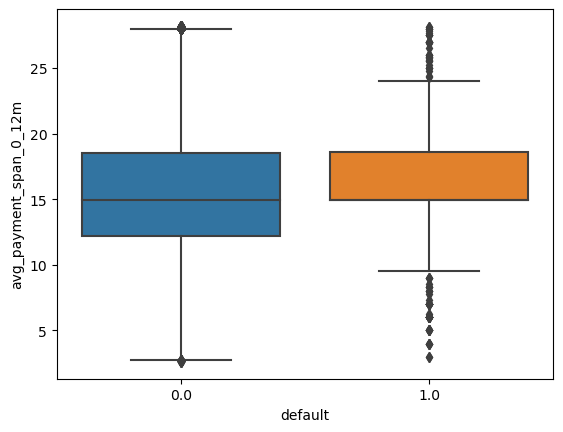

In [40]:
sns.boxplot(y = 'avg_payment_span_0_12m', data = pd_data, x = 'default')

In [41]:
pd_data[pd_data['default'] == 1]['has_paid'].value_counts(normalize = True)

1.0    0.799689
0.0    0.200311
Name: has_paid, dtype: float64

In [42]:
pd_data[pd_data['default'] == 0]['has_paid'].value_counts(normalize = True)

1.0    0.881754
0.0    0.118246
Name: has_paid, dtype: float64

<AxesSubplot:xlabel='has_paid', ylabel='count'>

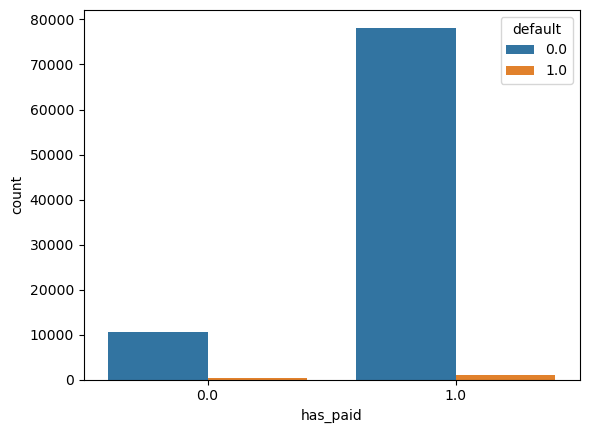

In [43]:
sns.countplot(x = 'has_paid', data = pd_data, hue = 'default')

<AxesSubplot:xlabel='default', ylabel='max_paid_inv_0_12m'>

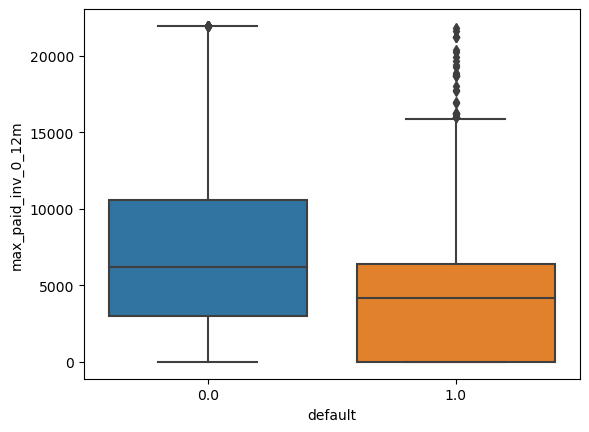

In [44]:
sns.boxplot(y = 'max_paid_inv_0_12m', data = pd_data, x = 'default')

<AxesSubplot:xlabel='default', ylabel='max_paid_inv_0_24m'>

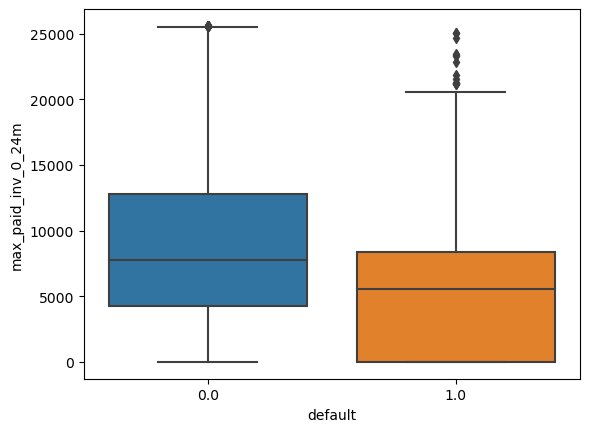

In [45]:
sns.boxplot(y = 'max_paid_inv_0_24m', data = pd_data, x = 'default')

<AxesSubplot:xlabel='count', ylabel='default'>

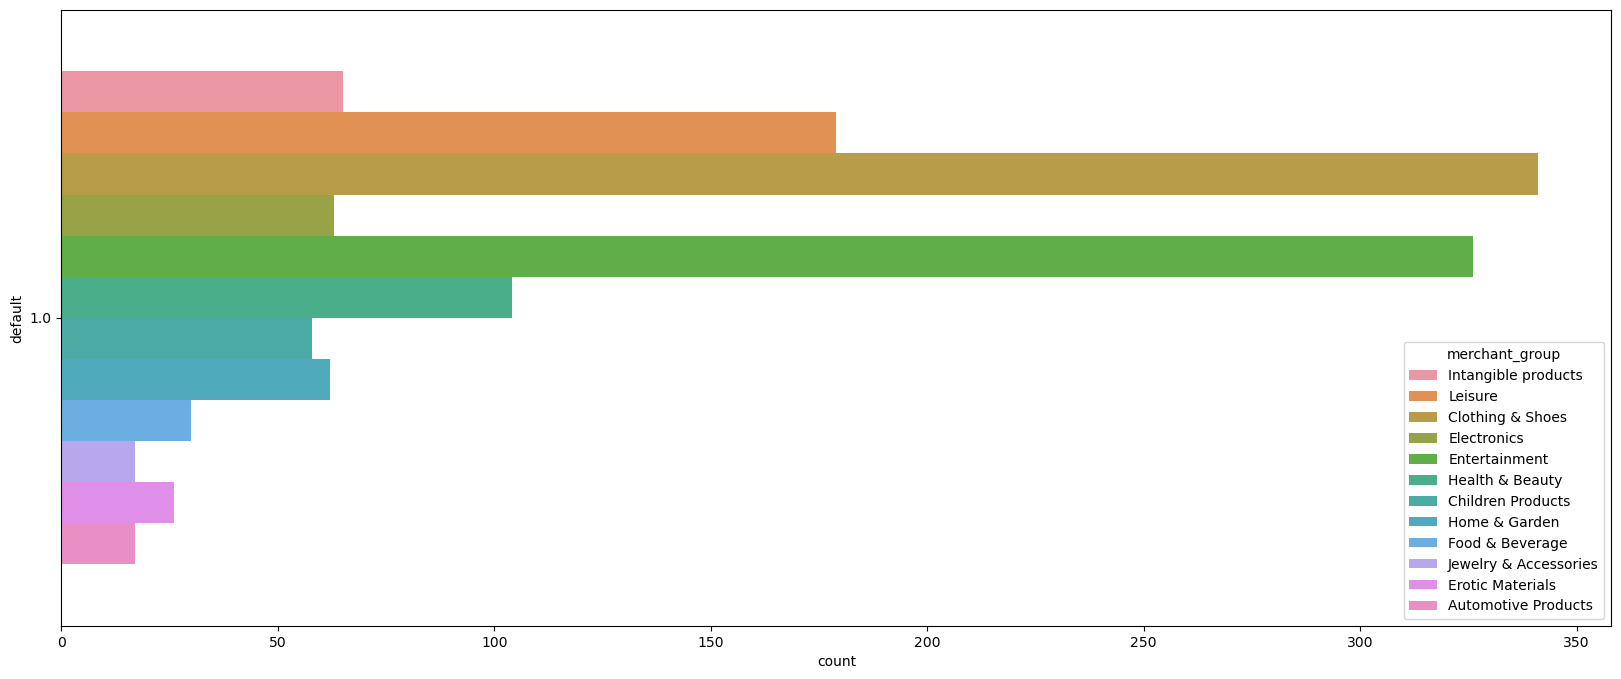

In [46]:
plt.figure(figsize=(20, 8))
sns.countplot(y = 'default', data = pd_data[pd_data['default']==1], hue = 'merchant_group')

<AxesSubplot:xlabel='count', ylabel='default'>

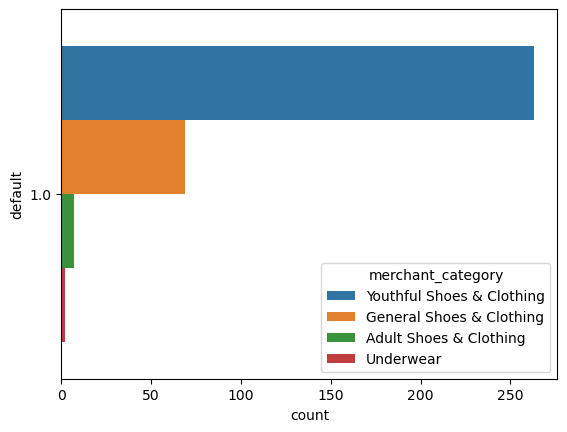

In [47]:
sns.countplot(y = 'default', data = pd_data[pd_data['default']==1][pd_data['merchant_group']=='Clothing & Shoes'], 
              hue = 'merchant_category')

<AxesSubplot:xlabel='count', ylabel='default'>

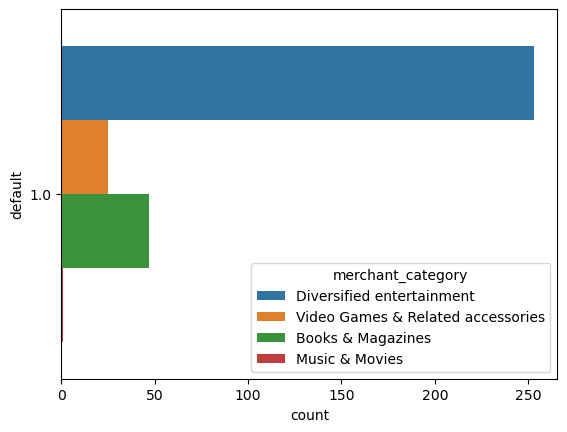

In [48]:
sns.countplot(y = 'default', data = pd_data[pd_data['default']==1][pd_data['merchant_group']=='Entertainment'], 
              hue = 'merchant_category')

<AxesSubplot:xlabel='default', ylabel='num_arch_ok_0_12m'>

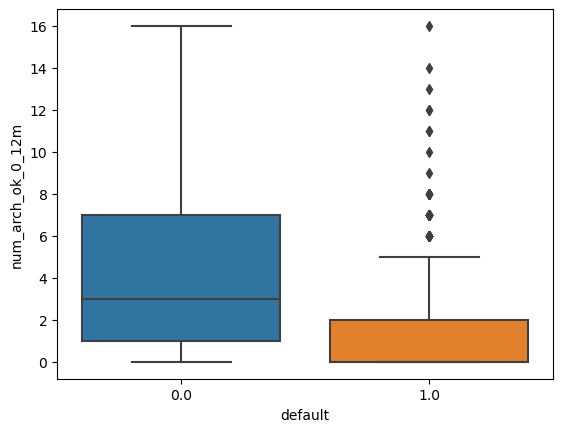

In [49]:
sns.boxplot(y = 'num_arch_ok_0_12m', data = pd_data, x = 'default')

<AxesSubplot:xlabel='default', ylabel='num_arch_ok_12_24m'>

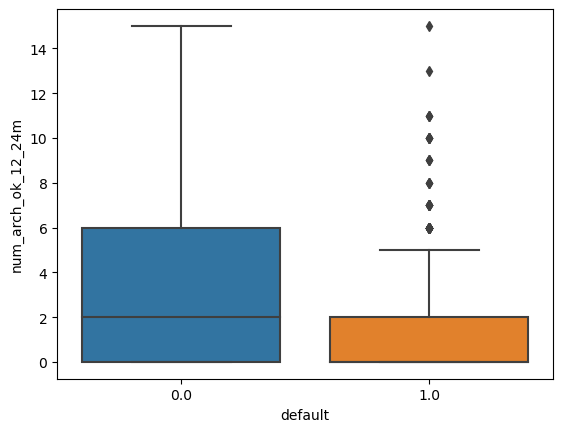

In [50]:
sns.boxplot(y = 'num_arch_ok_12_24m', data = pd_data, x = 'default')

<AxesSubplot:xlabel='default', ylabel='sum_paid_inv_0_12m'>

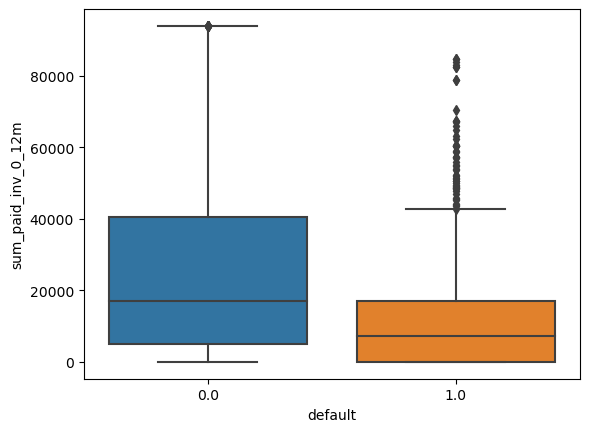

In [51]:
sns.boxplot(y = 'sum_paid_inv_0_12m', data = pd_data, x = 'default')

In [52]:
X = pd_data.drop(columns = ['default'])

In [53]:
X.head()

,acct_amt_added_12_24m,age,avg_payment_span_0_12m,merchant_category,merchant_group,has_paid,max_paid_inv_0_12m,max_paid_inv_0_24m,num_active_div_by_paid_inv_0_12m,num_active_inv,num_arch_ok_0_12m,num_arch_ok_12_24m,status_max_archived_0_6_months,status_max_archived_0_24_months,sum_capital_paid_acct_0_12m,sum_paid_inv_0_12m,time_hours
0,0.0,20.0,12.692308,Dietary supplements,Health & Beauty,1.0,10573.0,12800.0,0.028571,2.0,13.0,14.0,1.0,1.0,0.0,40533.5,9.653333
1,0.0,50.0,25.833333,Books & Magazines,Entertainment,1.0,13749.0,13749.0,0.000000,0.0,9.0,6.0,1.0,2.0,0.0,49014.0,13.181389
2,0.0,22.0,20.000000,Diversified entertainment,Entertainment,1.0,10573.0,12800.0,0.071429,1.0,11.0,0.0,1.0,2.0,0.0,40533.5,11.561944
3,0.0,36.0,4.687500,Diversified entertainment,Entertainment,1.0,10573.0,12800.0,0.031250,1.0,7.0,6.0,1.0,1.0,0.0,40533.5,15.751111
4,0.0,25.0,13.000000,Electronic equipment & Related accessories,Electronics,1.0,7100.0,7100.0,0.000000,0.0,1.0,0.0,1.0,1.0,0.0,7100.0,12.698611


In [54]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 89976 entries, 0 to 89975
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   acct_amt_added_12_24m             89976 non-null  float64
 1   age                               89976 non-null  float64
 2   avg_payment_span_0_12m            89976 non-null  float64
 3   merchant_category                 89976 non-null  object 
 4   merchant_group                    89976 non-null  object 
 5   has_paid                          89976 non-null  float64
 6   max_paid_inv_0_12m                89976 non-null  float64
 7   max_paid_inv_0_24m                89976 non-null  float64
 8   num_active_div_by_paid_inv_0_12m  89976 non-null  float64
 9   num_active_inv                    89976 non-null  float64
 10  num_arch_ok_0_12m                 89976 non-null  float64
 11  num_arch_ok_12_24m                89976 non-null  float64
 12  stat

In [55]:
X_Kmeans = X.drop(columns = ['merchant_category','merchant_group'])

In [56]:
from sklearn.cluster import KMeans 
wss = []
for i in range(1,20):
    KM = KMeans(n_clusters=i)
    KM.fit(X_Kmeans)
    wss.append(KM.inertia_)

In [57]:
wss

[48167015245079.32,
 16646201732981.547,
 10301649152552.873,
 6490859443142.257,
 5621291486665.646,
 4917761817008.263,
 4418479153092.162,
 4022952055695.6523,
 3748835928815.3687,
 3528372568402.8135,
 3324641579658.118,
 3158992217132.58,
 3022264487776.6616,
 2885521963809.6025,
 2771455859145.487,
 2657869066808.1826,
 2571431284560.2617,
 2474802983386.9014,
 2398529482882.832]

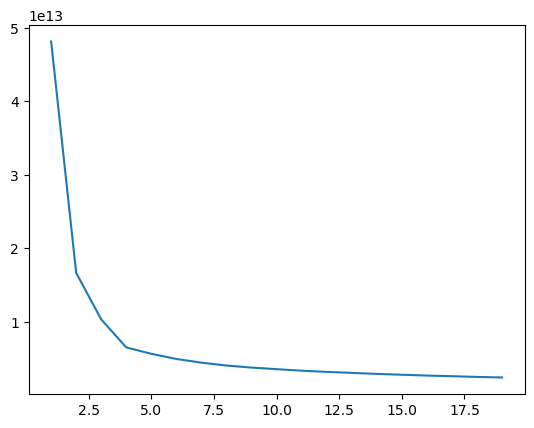

In [58]:
plt.plot(range(1,20), wss)

In [59]:
# Assigning clusters
k_means = KMeans(n_clusters = 4)
k_means.fit(X_Kmeans)
labels = k_means.labels_

In [60]:
X_Kmeans['Clus_kmeans'] = labels
X_Kmeans.head(10)

,acct_amt_added_12_24m,age,avg_payment_span_0_12m,has_paid,max_paid_inv_0_12m,max_paid_inv_0_24m,num_active_div_by_paid_inv_0_12m,num_active_inv,num_arch_ok_0_12m,num_arch_ok_12_24m,status_max_archived_0_6_months,status_max_archived_0_24_months,sum_capital_paid_acct_0_12m,sum_paid_inv_0_12m,time_hours,Clus_kmeans
0,0.00,20.0,12.692308,1.0,10573.0,12800.0,0.028571,2.0,13.0,14.0,1.0,1.0,0.0,40533.5,9.653333,0
1,0.00,50.0,25.833333,1.0,13749.0,13749.0,0.000000,0.0,9.0,6.0,1.0,2.0,0.0,49014.0,13.181389,0
2,0.00,22.0,20.000000,1.0,10573.0,12800.0,0.071429,1.0,11.0,0.0,1.0,2.0,0.0,40533.5,11.561944,0
3,0.00,36.0,4.687500,1.0,10573.0,12800.0,0.031250,1.0,7.0,6.0,1.0,1.0,0.0,40533.5,15.751111,0
4,0.00,25.0,13.000000,1.0,7100.0,7100.0,0.000000,0.0,1.0,0.0,1.0,1.0,0.0,7100.0,12.698611,2
5,0.00,18.0,14.904762,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.328333,2
6,0.00,49.0,3.000000,1.0,6180.0,7750.0,0.000000,0.0,3.0,2.0,1.0,1.0,0.0,17085.0,15.818611,1
7,4984.25,34.0,26.930233,1.0,8655.0,9645.0,0.028571,1.0,7.0,6.0,1.0,1.0,5685.0,40533.5,12.192778,0
8,4984.25,40.0,18.600000,1.0,6075.0,9090.0,0.028571,1.0,3.0,2.0,2.0,2.0,5685.0,24390.0,21.411111,1
9,0.00,47.0,21.000000,1.0,10573.0,12800.0,0.000000,0.0,5.0,10.0,1.0,1.0,0.0,78620.0,13.340833,3


In [61]:
X_Kmeans["Clus_kmeans"].value_counts().sort_index()

0    21793
1    31098
2    29613
3     7472
Name: Clus_kmeans, dtype: int64

In [62]:
clust_profile=X_Kmeans.groupby('Clus_kmeans').mean()
clust_profile['freq']=X_Kmeans['Clus_kmeans'].value_counts().sort_index()
clust_profile

,acct_amt_added_12_24m,age,avg_payment_span_0_12m,has_paid,max_paid_inv_0_12m,max_paid_inv_0_24m,num_active_div_by_paid_inv_0_12m,num_active_inv,num_arch_ok_0_12m,num_arch_ok_12_24m,status_max_archived_0_6_months,status_max_archived_0_24_months,sum_capital_paid_acct_0_12m,sum_paid_inv_0_12m,time_hours,freq
Clus_kmeans,,,,,,,,,,,,,,,,
0,2092.857122,35.211031,15.129126,1.000000,11232.337218,13138.072730,0.017566,0.630661,6.998302,5.455054,1.181434,1.621025,2648.254072,40706.850227,15.503688,21793
1,1632.577248,35.970191,15.091637,1.000000,7218.530098,8825.939353,0.005356,0.220722,3.403756,2.833140,0.951444,1.332883,1583.598688,17578.942408,15.643992,31098
2,845.081045,36.506095,14.602223,0.637153,1594.399081,2919.001520,0.002628,0.164624,0.682335,0.938642,0.285213,0.702799,1274.605410,2368.318239,15.502530,29613
3,2099.019138,34.785332,15.244797,1.000000,11404.317452,13399.984743,0.018112,0.640123,7.830300,5.805407,1.210921,1.635171,2659.666488,72505.531585,15.568405,7472


In [63]:
pd_data=pd.get_dummies(pd_data, columns = ['merchant_category', 'merchant_group'], drop_first = True)

In [64]:
# Splitting X and Y variables

X = pd_data.drop(columns = ['default'], axis=1)
y = pd_data['default']

In [65]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,random_state=123,test_size=0.30)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(62983, 82)
(62983,)
(26993, 82)
(26993,)


In [66]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [67]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
clf = LinearDiscriminantAnalysis()
model_lda=clf.fit(x_train, y_train)
model_lda

LinearDiscriminantAnalysis()

In [68]:
from sklearn import metrics
y_predict = model_lda.predict(x_test)
model_score = model_lda.score(x_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_predict))
print(metrics.classification_report(y_test, y_predict))

0.9788834142185011
[[26399   213]
 [  357    24]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     26612
           1       0.10      0.06      0.08       381

    accuracy                           0.98     26993
   macro avg       0.54      0.53      0.53     26993
weighted avg       0.97      0.98      0.98     26993



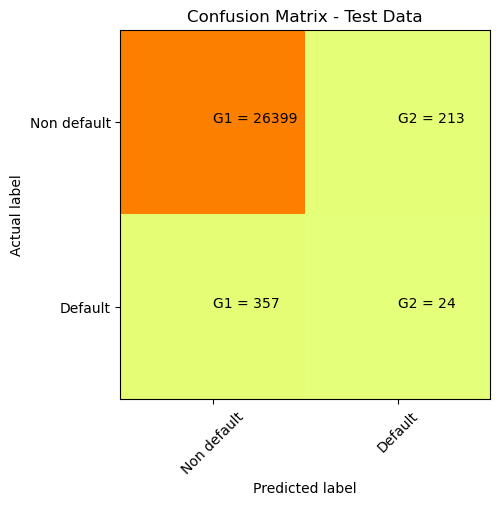

In [69]:
cm = metrics.confusion_matrix(y_test, y_predict)
plt.clf()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Wistia)
classNames = ['Non default', 'Default']
plt.title('Confusion Matrix - Test Data')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=45)
plt.yticks(tick_marks, classNames)
s = [['G1', 'G2'], ['G1','G2']]
 
for i in range(2):
    for j in range(2):
        plt.text(j,i, str(s[i][j])+" = "+str(cm[i][j]))
plt.show()

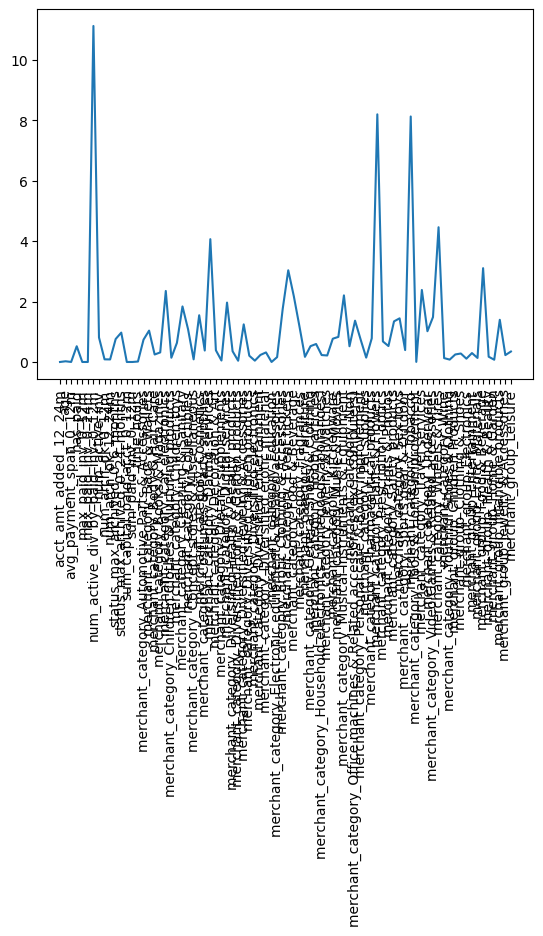

In [70]:
plt.xticks(rotation = 90)
plt.plot(X.columns, abs(model_lda.coef_[0]))

In [71]:
#comparing train and test accuracy for LDA model
y_predict_test = model_lda.predict(x_test)
model_score_test = model_lda.score(x_test, y_test)

y_predict_train = model_lda.predict(x_train)
model_score_train = model_lda.score(x_train, y_train)

print("test accuracy:", model_score_test)
print("train accuracy:", model_score_train)

test accuracy: 0.9788834142185011
train accuracy: 0.9781687121921788


In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
LR_model = LogisticRegression()
LR_model.fit(x_train, y_train)
y_predict = LR_model.predict(x_test)
model_score = LR_model.score(x_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_predict))
print(metrics.classification_report(y_test, y_predict))

0.9858852295039454
[[26612     0]
 [  381     0]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     26612
           1       0.00      0.00      0.00       381

    accuracy                           0.99     26993
   macro avg       0.49      0.50      0.50     26993
weighted avg       0.97      0.99      0.98     26993



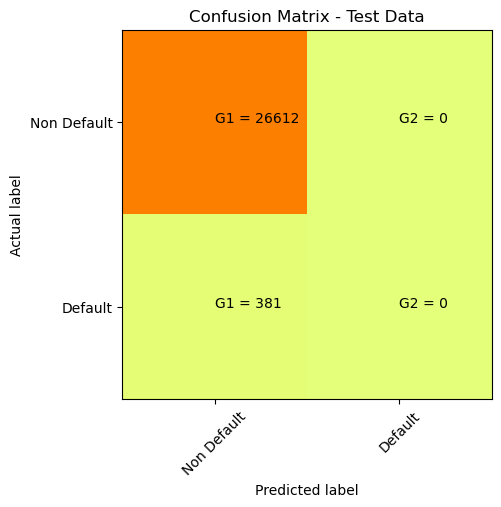

In [73]:
cm = metrics.confusion_matrix(y_test, y_predict)
plt.clf()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Wistia)
classNames = ['Non Default', 'Default']
plt.title('Confusion Matrix - Test Data')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=45)
plt.yticks(tick_marks, classNames)
s = [['G1', 'G2'], ['G1','G2']]
 
for i in range(2):
    for j in range(2):
        plt.text(j,i, str(s[i][j])+" = "+str(cm[i][j]))
plt.show()

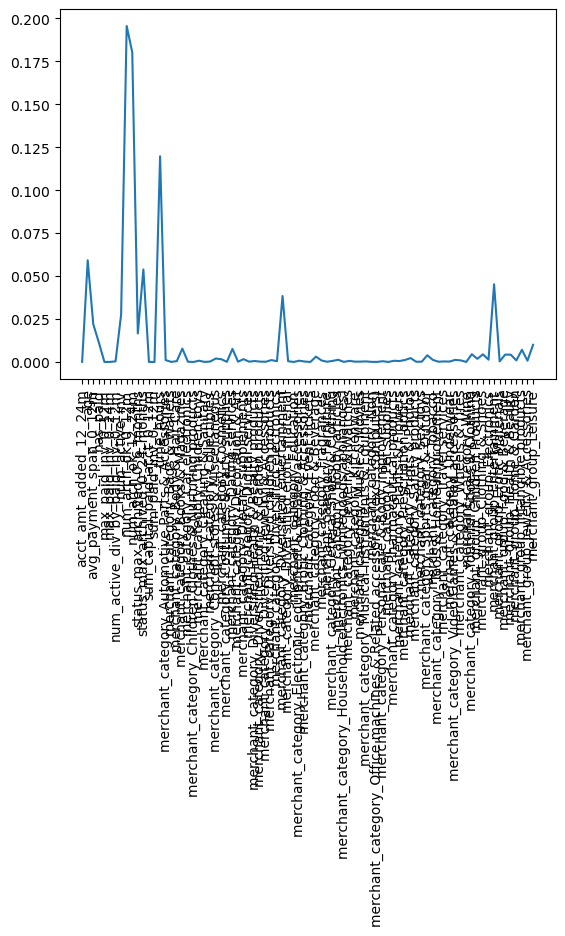

In [74]:
plt.xticks(rotation = 90)
plt.plot(X.columns, abs(LR_model.coef_[0]))

In [75]:
#comparing train and test accuracy for LR model
y_predict_test = LR_model.predict(x_test)
model_score_test = LR_model.score(x_test, y_test)

y_predict_train = LR_model.predict(x_train)
model_score_train = LR_model.score(x_train, y_train)

print("test accuracy:", model_score_test)
print("train accuracy:", model_score_train)

test accuracy: 0.9858852295039454
train accuracy: 0.98559928869695


In [76]:
from sklearn.naive_bayes import GaussianNB
NB_model = GaussianNB()
NB_model.fit(x_train, y_train)
print(NB_model)
# make predictions
expected = y_test
predicted = NB_model.predict(x_test)
# summarize the fit of the model
print(metrics.classification_report(expected, predicted))
print(metrics.confusion_matrix(expected, predicted))

GaussianNB()
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     26612
           1       0.09      0.13      0.11       381

    accuracy                           0.97     26993
   macro avg       0.54      0.55      0.55     26993
weighted avg       0.97      0.97      0.97     26993

[[26154   458]
 [  333    48]]


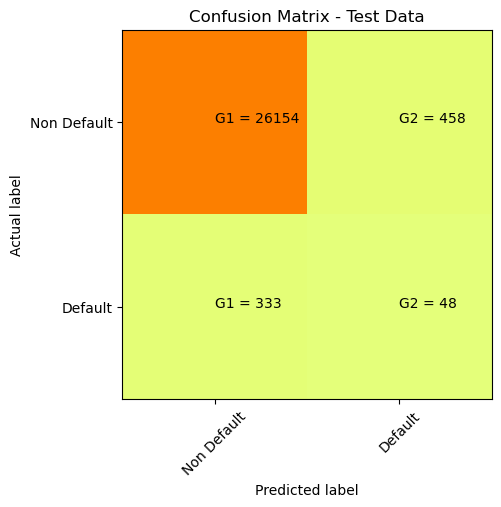

In [77]:
cm = metrics.confusion_matrix(expected, predicted)
plt.clf()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Wistia)
classNames = ['Non Default', 'Default']
plt.title('Confusion Matrix - Test Data')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=45)
plt.yticks(tick_marks, classNames)
s = [['G1', 'G2'], ['G1','G2']]
 
for i in range(2):
    for j in range(2):
        plt.text(j,i, str(s[i][j])+" = "+str(cm[i][j]))
plt.show()

In [78]:
#comparing train and test accuracy for Gaussian NB model
y_predict_test = NB_model.predict(x_test)
model_score_test = NB_model.score(x_test, y_test)

y_predict_train = NB_model.predict(x_train)
model_score_train = NB_model.score(x_train, y_train)

print("test accuracy:", model_score_test)
print("train accuracy:", model_score_train)

test accuracy: 0.970696106397955
train accuracy: 0.970944540590318


In [79]:
#Applying KNN
from sklearn.neighbors import KNeighborsClassifier
NNH = KNeighborsClassifier(n_neighbors= 5 , weights = 'distance' )
NNH.fit(x_train, y_train)
print(NNH)

# make predictions
expected = y_test
predicted = NNH.predict(x_test)
# summarize the fit of the model
print(metrics.classification_report(expected, predicted))
print(metrics.confusion_matrix(expected, predicted))

KNeighborsClassifier(weights='distance')
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     26612
           1       0.31      0.09      0.14       381

    accuracy                           0.98     26993
   macro avg       0.65      0.54      0.57     26993
weighted avg       0.98      0.98      0.98     26993

[[26534    78]
 [  346    35]]


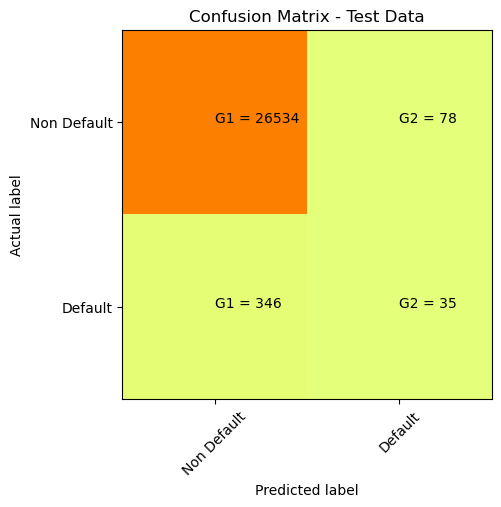

In [80]:
cm = metrics.confusion_matrix(expected, predicted)
plt.clf()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Wistia)
classNames = ['Non Default', 'Default']
plt.title('Confusion Matrix - Test Data')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=45)
plt.yticks(tick_marks, classNames)
s = [['G1', 'G2'], ['G1','G2']]
 
for i in range(2):
    for j in range(2):
        plt.text(j,i, str(s[i][j])+" = "+str(cm[i][j]))
plt.show()

In [81]:
#comparing train and test accuracy for Gaussian NB model
y_predict_test = NNH.predict(x_test)
model_score_test = NNH.score(x_test, y_test)

y_predict_train = NNH.predict(x_train)
model_score_train = NNH.score(x_train, y_train)

print("test accuracy:", model_score_test)
print("train accuracy:", model_score_train)

test accuracy: 0.9842922239099026
train accuracy: 0.9986980613816426


In [82]:
#Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier
dTree = DecisionTreeClassifier(criterion = 'gini', random_state=123)
dTree.fit(x_train, y_train)

expected = y_test
predicted = dTree.predict(x_test)
# summarize the fit of the model
print(metrics.classification_report(expected, predicted))
print(metrics.confusion_matrix(expected, predicted))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     26612
           1       0.14      0.14      0.14       381

    accuracy                           0.98     26993
   macro avg       0.56      0.56      0.56     26993
weighted avg       0.98      0.98      0.98     26993

[[26279   333]
 [  327    54]]


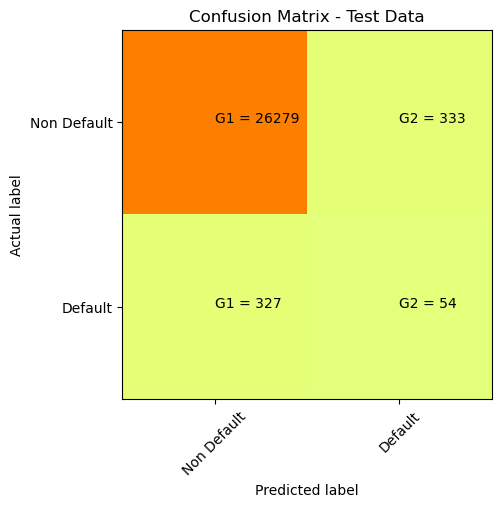

In [83]:
cm = metrics.confusion_matrix(expected, predicted)
plt.clf()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Wistia)
classNames = ['Non Default', 'Default']
plt.title('Confusion Matrix - Test Data')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=45)
plt.yticks(tick_marks, classNames)
s = [['G1', 'G2'], ['G1','G2']]
 
for i in range(2):
    for j in range(2):
        plt.text(j,i, str(s[i][j])+" = "+str(cm[i][j]))
plt.show()

In [84]:
#comparing train and test accuracy for Gaussian NB model
y_predict_test = dTree.predict(x_test)
model_score_test = dTree.score(x_test, y_test)

y_predict_train = dTree.predict(x_train)
model_score_train = dTree.score(x_train, y_train)

print("test accuracy:", model_score_test)
print("train accuracy:", model_score_train)

test accuracy: 0.9755492164635275
train accuracy: 0.9986980613816426


In [85]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [86]:
from imblearn.over_sampling import SMOTE

In [87]:
smote = SMOTE(sampling_strategy='auto', random_state=42)
x_resampled, y_resampled = smote.fit_resample(x_train, y_train)

In [88]:
y_resampled.value_counts()

0    62076
1    62076
Name: default, dtype: int64

In [89]:
x_resampled.shape

(124152, 82)

In [90]:
clf = LinearDiscriminantAnalysis()
model_lda=clf.fit(x_resampled, y_resampled)
model_lda

y_predict = model_lda.predict(x_test)
model_score = model_lda.score(x_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_predict))
print(metrics.classification_report(y_test, y_predict))

0.9761419627310784
[[26316   296]
 [  348    33]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     26612
           1       0.10      0.09      0.09       381

    accuracy                           0.98     26993
   macro avg       0.54      0.54      0.54     26993
weighted avg       0.97      0.98      0.98     26993



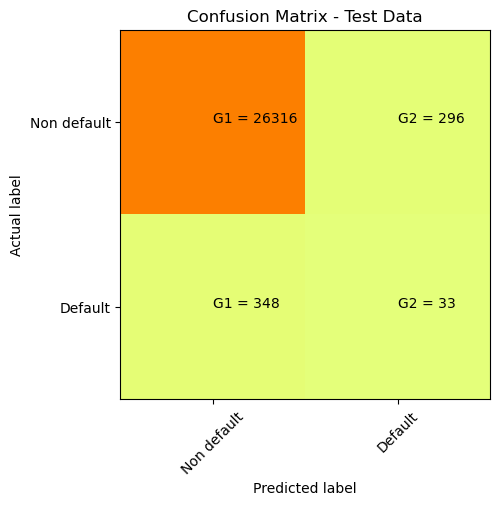

In [91]:
cm = metrics.confusion_matrix(y_test, y_predict)
plt.clf()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Wistia)
classNames = ['Non default', 'Default']
plt.title('Confusion Matrix - Test Data')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=45)
plt.yticks(tick_marks, classNames)
s = [['G1', 'G2'], ['G1','G2']]
 
for i in range(2):
    for j in range(2):
        plt.text(j,i, str(s[i][j])+" = "+str(cm[i][j]))
plt.show()

In [92]:
LR = LogisticRegression()
model=LR.fit(x_resampled, y_resampled)
model

y_predict = model.predict(x_test)
model_score = model.score(x_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_predict))
print(metrics.classification_report(y_test, y_predict))

0.6477234838661875
[[17186  9426]
 [   83   298]]
              precision    recall  f1-score   support

           0       1.00      0.65      0.78     26612
           1       0.03      0.78      0.06       381

    accuracy                           0.65     26993
   macro avg       0.51      0.71      0.42     26993
weighted avg       0.98      0.65      0.77     26993



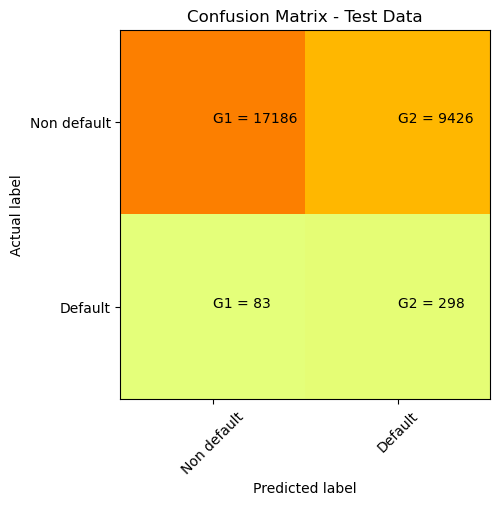

In [93]:
cm = metrics.confusion_matrix(y_test, y_predict)
plt.clf()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Wistia)
classNames = ['Non default', 'Default']
plt.title('Confusion Matrix - Test Data')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=45)
plt.yticks(tick_marks, classNames)
s = [['G1', 'G2'], ['G1','G2']]
 
for i in range(2):
    for j in range(2):
        plt.text(j,i, str(s[i][j])+" = "+str(cm[i][j]))
plt.show()

In [94]:
#comparing train and test accuracy for LDA model
y_predict_test = model_lda.predict(x_test)
model_score_test = model_lda.score(x_test, y_test)

y_predict_train = model_lda.predict(x_train)
model_score_train = model_lda.score(x_train, y_train)

print("test accuracy:", model_score_test)
print("train accuracy:", model_score_train)

test accuracy: 0.9761419627310784
train accuracy: 0.9761999269644189


In [95]:
#comparing train and test accuracy for LR model
y_predict_test = model.predict(x_test)
model_score_test = model.score(x_test, y_test)

y_predict_train = model.predict(x_train)
model_score_train = model.score(x_train, y_train)

print("test accuracy:", model_score_test)
print("train accuracy:", model_score_train)

test accuracy: 0.6477234838661875
train accuracy: 0.651731419589413


In [96]:
GNB = GaussianNB()
model=GNB.fit(x_resampled, y_resampled)
model

y_predict = model.predict(x_test)
model_score = model.score(x_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_predict))
print(metrics.classification_report(y_test, y_predict))

0.5192086837328196
[[13679 12933]
 [   45   336]]
              precision    recall  f1-score   support

           0       1.00      0.51      0.68     26612
           1       0.03      0.88      0.05       381

    accuracy                           0.52     26993
   macro avg       0.51      0.70      0.36     26993
weighted avg       0.98      0.52      0.67     26993



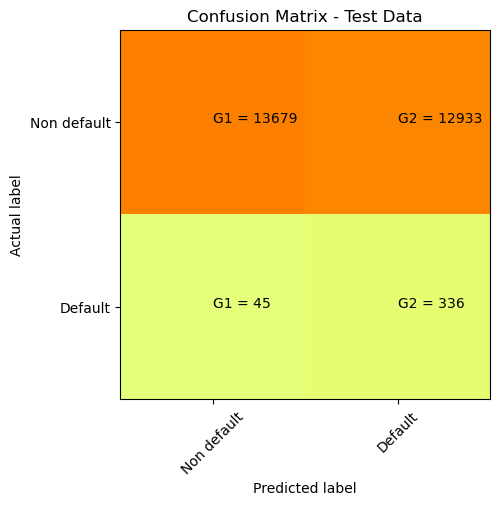

In [97]:
cm = metrics.confusion_matrix(y_test, y_predict)
plt.clf()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Wistia)
classNames = ['Non default', 'Default']
plt.title('Confusion Matrix - Test Data')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=45)
plt.yticks(tick_marks, classNames)
s = [['G1', 'G2'], ['G1','G2']]
 
for i in range(2):
    for j in range(2):
        plt.text(j,i, str(s[i][j])+" = "+str(cm[i][j]))
plt.show()

In [98]:
#comparing train and test accuracy for GNB model
y_predict_test = model.predict(x_test)
model_score_test = model.score(x_test, y_test)

y_predict_train = model.predict(x_train)
model_score_train = model.score(x_train, y_train)

print("test accuracy:", model_score_test)
print("train accuracy:", model_score_train)

test accuracy: 0.5192086837328196
train accuracy: 0.5214740485527841


In [99]:
NNH = KNeighborsClassifier(n_neighbors= 5 , weights = 'distance' )
NNH.fit(x_resampled, y_resampled)
print(NNH)

# make predictions
expected = y_test
predicted = NNH.predict(x_test)
# summarize the fit of the model
print(metrics.classification_report(expected, predicted))
print(metrics.confusion_matrix(expected, predicted))

KNeighborsClassifier(weights='distance')
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     26612
           1       0.04      0.30      0.07       381

    accuracy                           0.88     26993
   macro avg       0.51      0.60      0.50     26993
weighted avg       0.98      0.88      0.92     26993

[[23686  2926]
 [  266   115]]


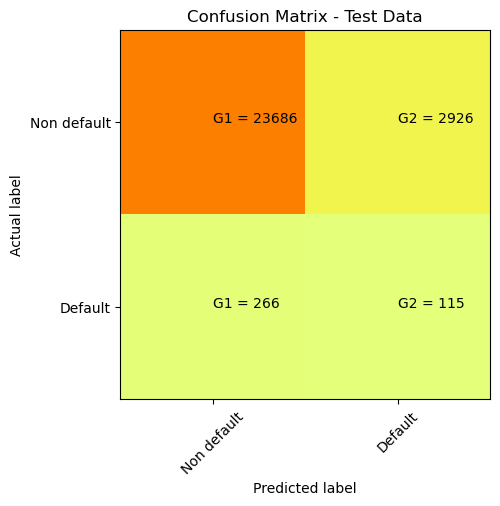

In [100]:
cm = metrics.confusion_matrix(expected, predicted)
plt.clf()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Wistia)
classNames = ['Non default', 'Default']
plt.title('Confusion Matrix - Test Data')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=45)
plt.yticks(tick_marks, classNames)
s = [['G1', 'G2'], ['G1','G2']]
 
for i in range(2):
    for j in range(2):
        plt.text(j,i, str(s[i][j])+" = "+str(cm[i][j]))
plt.show()

In [101]:
#comparing train and test accuracy for KNN model
y_predict_test = NNH.predict(x_test)
model_score_test = NNH.score(x_test, y_test)

y_predict_train = NNH.predict(x_train)
model_score_train = NNH.score(x_train, y_train)

print("test accuracy:", model_score_test)
print("train accuracy:", model_score_train)

test accuracy: 0.8817471196236061
train accuracy: 0.9980153374720162


In [102]:
dTree = DecisionTreeClassifier(criterion = 'gini', random_state=123)
dTree.fit(x_resampled, y_resampled)

expected = y_test
predicted = dTree.predict(x_test)
# summarize the fit of the model
print(metrics.classification_report(expected, predicted))
print(metrics.confusion_matrix(expected, predicted))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98     26612
           1       0.09      0.13      0.11       381

    accuracy                           0.97     26993
   macro avg       0.54      0.56      0.55     26993
weighted avg       0.97      0.97      0.97     26993

[[26126   486]
 [  331    50]]


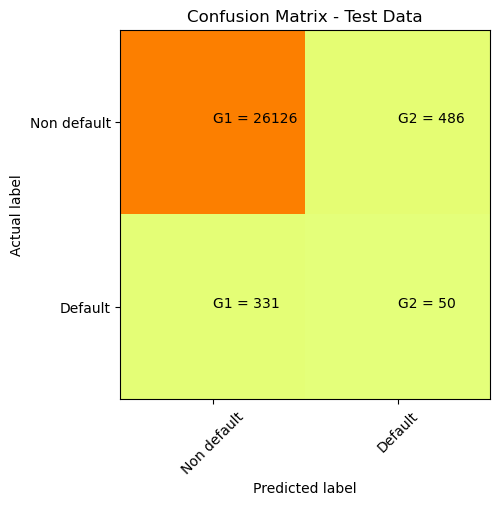

In [103]:
cm = metrics.confusion_matrix(expected, predicted)
plt.clf()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Wistia)
classNames = ['Non default', 'Default']
plt.title('Confusion Matrix - Test Data')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=45)
plt.yticks(tick_marks, classNames)
s = [['G1', 'G2'], ['G1','G2']]
 
for i in range(2):
    for j in range(2):
        plt.text(j,i, str(s[i][j])+" = "+str(cm[i][j]))
plt.show()

In [104]:
#comparing train and test accuracy for Decision Tree model
y_predict_test = dTree.predict(x_test)
model_score_test = dTree.score(x_test, y_test)

y_predict_train = dTree.predict(x_train)
model_score_train = dTree.score(x_train, y_train)

print("test accuracy:", model_score_test)
print("train accuracy:", model_score_train)

test accuracy: 0.9697328937131849
train accuracy: 0.9978248098693299


0.5192086837328196


<AxesSubplot:>

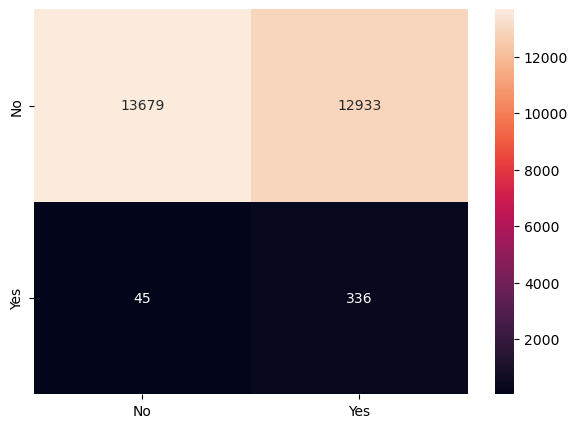

In [105]:
from sklearn.ensemble import BaggingClassifier

bgcl = BaggingClassifier(base_estimator=GNB, n_estimators=100,random_state=1)
#bgcl = BaggingClassifier(n_estimators=50,random_state=1)

bgcl = bgcl.fit(x_resampled, y_resampled)

y_predict = bgcl.predict(x_test)

print(bgcl.score(x_test , y_test))

cm=metrics.confusion_matrix(y_test, y_predict,labels=[0, 1])

df_cm = pd.DataFrame(cm, index = [i for i in ["No","Yes"]],
                  columns = [i for i in ["No","Yes"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_cm, annot=True ,fmt='g')

0.9449486904012151


<AxesSubplot:>

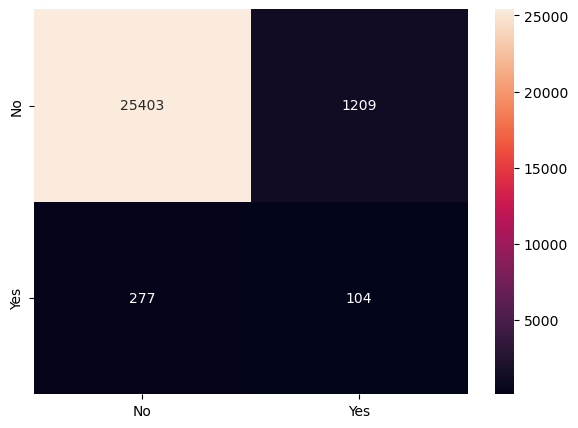

In [106]:
# Ada Boosting
from sklearn.ensemble import AdaBoostClassifier
abcl = AdaBoostClassifier(n_estimators=100, random_state=123)
#abcl = AdaBoostClassifier( n_estimators=50,random_state=1)
abcl = abcl.fit(x_resampled, y_resampled)

y_predict = abcl.predict(x_test)
print(abcl.score(x_test , y_test))

cm=metrics.confusion_matrix(y_test, y_predict,labels=[0, 1])

df_cm = pd.DataFrame(cm, index = [i for i in ["No","Yes"]],
                  columns = [i for i in ["No","Yes"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_cm, annot=True ,fmt='g')

0.9477642351720816


<AxesSubplot:>

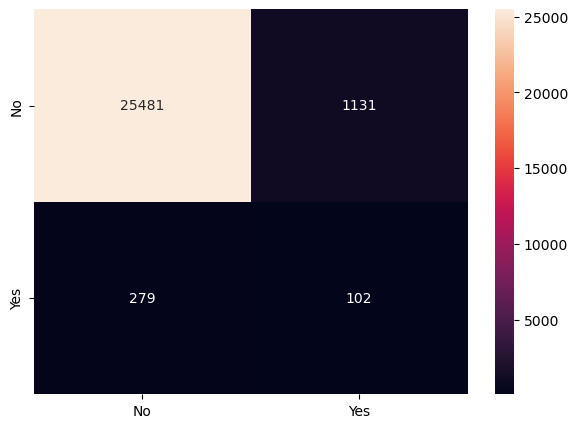

In [107]:
#Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
gbcl = GradientBoostingClassifier(n_estimators = 100,random_state=1)
gbcl = gbcl.fit(x_resampled, y_resampled)

y_predict = gbcl.predict(x_test)
print(gbcl.score(x_test, y_test))
cm=metrics.confusion_matrix(y_test, y_predict,labels=[0, 1])

df_cm = pd.DataFrame(cm, index = [i for i in ["No","Yes"]],
                  columns = [i for i in ["No","Yes"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_cm, annot=True ,fmt='g')

In [108]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score

bagging_clf = BaggingClassifier(base_estimator=GNB, random_state=42)

# Define the hyperparameter grid to search
param_grid = {
    'n_estimators': [10, 50, 100],
}

# Create GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(bagging_clf, param_grid, scoring='recall', cv=5)
grid_search.fit(x_resampled, y_resampled)

# Get the best hyperparameters
best_params = grid_search.best_params_

# Train the model with the best hyperparameters on the entire training set
best_bagging_clf = grid_search.best_estimator_
best_bagging_clf.fit(x_resampled, y_resampled)

# Make predictions on the test set
y_pred = best_bagging_clf.predict(x_test)

# Calculate recall using the recall_score function
recall = recall_score(y_test, y_pred)

print("Best Hyperparameters:", best_params)
print("Recall on Test Set:", recall)

Best Hyperparameters: {'n_estimators': 100}
Recall on Test Set: 0.8818897637795275


In [109]:
ada_clf = AdaBoostClassifier(base_estimator=GNB, random_state=42)

# Define the hyperparameter grid to search
param_grid = {
    'n_estimators': [10, 50, 100],
}

# Create GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(ada_clf, param_grid, scoring='recall', cv=5)
grid_search.fit(x_resampled, y_resampled)

# Get the best hyperparameters
best_params = grid_search.best_params_

# Train the model with the best hyperparameters on the entire training set
best_ada_clf = grid_search.best_estimator_
best_ada_clf.fit(x_resampled, y_resampled)

# Make predictions on the test set
y_pred = best_ada_clf.predict(x_test)

# Calculate recall using the recall_score function
recall = recall_score(y_test, y_pred)

print("Best Hyperparameters:", best_params)
print("Recall on Test Set:", recall)

Best Hyperparameters: {'n_estimators': 10}
Recall on Test Set: 0.09711286089238845


In [110]:
gb_clf = GradientBoostingClassifier(random_state=42)

# Define the hyperparameter grid to search
param_grid = {
    'n_estimators': [10, 50, 100],
}

grid_search = GridSearchCV(gb_clf, param_grid, scoring='recall', cv=5)
grid_search.fit(x_resampled, y_resampled)

# Get the best hyperparameters
best_params = grid_search.best_params_

# Train the model with the best hyperparameters on the entire training set
best_gb_clf = grid_search.best_estimator_
best_gb_clf.fit(x_resampled, y_resampled)

# Make predictions on the test set
y_pred = best_gb_clf.predict(x_test)

# Calculate recall using the recall_score function
recall = recall_score(y_test, y_pred)

print("Best Hyperparameters:", best_params)
print("Recall on Test Set:", recall)

Best Hyperparameters: {'n_estimators': 10}
Recall on Test Set: 0.6141732283464567


In [111]:
from sklearn.metrics import roc_auc_score

# LDA AUC
probs = model_lda.predict_proba(x_test)
# keep probabilities for the pos outcome only
probs = probs[:, 1]
auc = roc_auc_score(y_test, probs)
print('AUC for LDA: %.3f' % auc)

#LR AUC
LR = LogisticRegression()
model_LR=LR.fit(x_resampled, y_resampled)
probs = model_LR.predict_proba(x_test)
# keep probabilities for the pos outcome only
probs = probs[:, 1]
auc = roc_auc_score(y_test, probs)
print('AUC for LR: %.3f' % auc)

# GNB AUC
probs = model.predict_proba(x_test)
# keep probabilities for the pos outcome only
probs = probs[:, 1]
auc = roc_auc_score(y_test, probs)
print('AUC for GNB: %.3f' % auc)

# KNN AUC
probs = NNH.predict_proba(x_test)
# keep probabilities for the pos outcome only
probs = probs[:, 1]
auc = roc_auc_score(y_test, probs)
print('AUC for KNN: %.3f' % auc)

# Decision Tree AUC
probs = dTree.predict_proba(x_test)
# keep probabilities for the pos outcome only
probs = probs[:, 1]
auc = roc_auc_score(y_test, probs)
print('AUC for Decision Tree: %.3f' % auc)

# Bagging AUC
probs = best_bagging_clf.predict_proba(x_test)
# keep probabilities for the pos outcome only
probs = probs[:, 1]
auc = roc_auc_score(y_test, probs)
print('AUC for Bagging: %.3f' % auc)

# Ada Boosting AUC
probs = best_ada_clf.predict_proba(x_test)
# keep probabilities for the pos outcome only
probs = probs[:, 1]
auc = roc_auc_score(y_test, probs)
print('AUC for Ada Boosting: %.3f' % auc)

# Grad Boosting AUC
probs = best_gb_clf.predict_proba(x_test)
# keep probabilities for the pos outcome only
probs = probs[:, 1]
auc = roc_auc_score(y_test, probs)
print('AUC for Grad Boosting: %.3f' % auc)

AUC for LDA: 0.762
AUC for LR: 0.776
AUC for GNB: 0.782
AUC for KNN: 0.628
AUC for Decision Tree: 0.562
AUC for Bagging: 0.782
AUC for Ada Boosting: 0.670
AUC for Grad Boosting: 0.784


In [112]:
means = pd.DataFrame(GNB.theta_, columns=x_train.columns)
print(means)

   acct_amt_added_12_24m        age  avg_payment_span_0_12m  has_paid  \
0            1516.306145  35.922289               14.917594  0.881758   
1            2035.424418  31.541377               16.268027  0.801284   

   max_paid_inv_0_12m  max_paid_inv_0_24m  num_active_div_by_paid_inv_0_12m  \
0         6710.934741         8347.174850                          0.008470   
1         4582.677816         5708.878814                          0.007551   

   num_active_inv  num_arch_ok_0_12m  num_arch_ok_12_24m  ...  \
0        0.335089           3.775420            3.121851  ...   
1        0.413692           1.233812            0.973075  ...   

   merchant_group_Clothing & Shoes  merchant_group_Electronics  \
0                         0.164476                    0.030028   
1                         0.106982                    0.005187   

   merchant_group_Entertainment  merchant_group_Erotic Materials  \
0                      0.492461                         0.006991   
1          